Taking a look at NASA Solar data
=

In [1]:
import requests
import pandas as pd
import numpy as np

In [2]:
url = "https://power.larc.nasa.gov/api/temporal/hourly/point"

params = {
    "parameters": "ALLSKY_SFC_SW_DWN,T2M",
    "community": "RE",
    "longitude": 77.1025,
    "latitude": 28.7041,
    "start": "20240101", # 2024 Jan 1st to 7th data 
    "end": "20240107",
    "format": "JSON"
}

response = requests.get(url, params=params)
data = response.json()

In [3]:
df = pd.DataFrame(data['properties']['parameter'])
df = df.reset_index().rename(columns={'index': 'datetime'})
df['datetime'] = pd.to_datetime(df['datetime'], format='%Y%m%d%H')

df.head()

,datetime,ALLSKY_SFC_SW_DWN,T2M
0,2024-01-01 00:00:00,0.0,9.47
1,2024-01-01 01:00:00,0.0,8.15
2,2024-01-01 02:00:00,0.0,7.08
3,2024-01-01 03:00:00,0.0,6.34
4,2024-01-01 04:00:00,0.0,5.81


In [4]:
df.describe()

,ALLSKY_SFC_SW_DWN,T2M
count,168.000000,168.000000
mean,60.007262,11.566607
std,99.272339,4.914007
min,0.000000,4.780000
25%,0.000000,7.115000
50%,0.000000,10.535000
75%,88.342500,16.082500
max,445.600000,21.140000


In [5]:
df.rename(columns={
    'ALLSKY_SFC_SW_DWN': 'irradiance',
    'T2M': 'temperature'
}, inplace=True)

In [6]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day

In [7]:
eta_base = 0.18
beta = 0.004

df['eta_eff'] = eta_base * (1 - beta * (df['temperature'] - 25))

# avoid negative values
df['eta_eff'] = df['eta_eff'].clip(lower=0)

In [8]:
P_rated = 1  # 1 kW system

df['energy'] = df['irradiance'] * df['eta_eff'] * P_rated

In [9]:
df[['datetime', 'irradiance', 'temperature', 'eta_eff', 'energy']].head(10)

,datetime,irradiance,temperature,eta_eff,energy
0,2024-01-01 00:00:00,0.00,9.47,0.191182,0.000000
1,2024-01-01 01:00:00,0.00,8.15,0.192132,0.000000
2,2024-01-01 02:00:00,0.00,7.08,0.192902,0.000000
3,2024-01-01 03:00:00,0.00,6.34,0.193435,0.000000
4,2024-01-01 04:00:00,0.00,5.81,0.193817,0.000000
5,2024-01-01 05:00:00,0.00,5.44,0.194083,0.000000
6,2024-01-01 06:00:00,0.00,5.27,0.194206,0.000000
7,2024-01-01 07:00:00,44.22,7.10,0.192888,8.529507
8,2024-01-01 08:00:00,98.50,9.97,0.190822,18.795928
9,2024-01-01 09:00:00,146.60,13.33,0.188402,27.619792


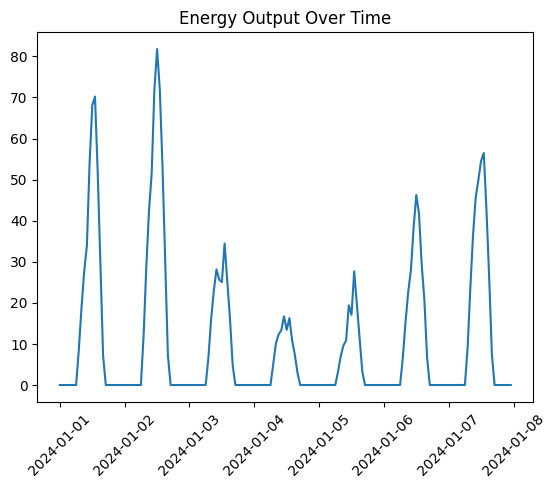

In [10]:
import matplotlib.pyplot as plt

plt.plot(df['datetime'], df['energy'])
plt.xticks(rotation=45)
plt.title("Energy Output Over Time")
plt.show()

In [11]:
df['hour'] = df['datetime'].dt.hour
df['dayofyear'] = df['datetime'].dt.dayofyear
df['month'] = df['datetime'].dt.month

In [13]:
df.head(10)

,datetime,irradiance,temperature,hour,day,eta_eff,energy,dayofyear,month
0,2024-01-01 00:00:00,0.00,9.47,0,1,0.191182,0.000000,1,1
1,2024-01-01 01:00:00,0.00,8.15,1,1,0.192132,0.000000,1,1
2,2024-01-01 02:00:00,0.00,7.08,2,1,0.192902,0.000000,1,1
3,2024-01-01 03:00:00,0.00,6.34,3,1,0.193435,0.000000,1,1
4,2024-01-01 04:00:00,0.00,5.81,4,1,0.193817,0.000000,1,1
5,2024-01-01 05:00:00,0.00,5.44,5,1,0.194083,0.000000,1,1
6,2024-01-01 06:00:00,0.00,5.27,6,1,0.194206,0.000000,1,1
7,2024-01-01 07:00:00,44.22,7.10,7,1,0.192888,8.529507,1,1
8,2024-01-01 08:00:00,98.50,9.97,8,1,0.190822,18.795928,1,1
9,2024-01-01 09:00:00,146.60,13.33,9,1,0.188402,27.619792,1,1


In [15]:
df.describe()

,irradiance,temperature,hour,day,eta_eff,energy,dayofyear,month
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.0
mean,60.007262,11.566607,11.500000,4.000000,0.189672,11.129406,4.000000,1.0
std,99.272339,4.914007,6.942881,2.005979,0.003538,18.306760,2.005979,0.0
min,0.000000,4.780000,0.000000,1.000000,0.182779,0.000000,1.000000,1.0
25%,0.000000,7.115000,5.750000,2.000000,0.186421,0.000000,2.000000,1.0
50%,0.000000,10.535000,11.500000,4.000000,0.190415,0.000000,4.000000,1.0
75%,88.342500,16.082500,17.250000,6.000000,0.192877,16.390767,6.000000,1.0
max,445.600000,21.140000,23.000000,7.000000,0.194558,81.796118,7.000000,1.0


In [16]:
df

,datetime,irradiance,temperature,hour,day,eta_eff,energy,dayofyear,month
0,2024-01-01 00:00:00,0.0,9.47,0,1,0.191182,0.0,1,1
1,2024-01-01 01:00:00,0.0,8.15,1,1,0.192132,0.0,1,1
2,2024-01-01 02:00:00,0.0,7.08,2,1,0.192902,0.0,1,1
3,2024-01-01 03:00:00,0.0,6.34,3,1,0.193435,0.0,1,1
4,2024-01-01 04:00:00,0.0,5.81,4,1,0.193817,0.0,1,1
...,...,...,...,...,...,...,...,...,...
163,2024-01-07 19:00:00,0.0,12.53,19,7,0.188978,0.0,7,1
164,2024-01-07 20:00:00,0.0,11.79,20,7,0.189511,0.0,7,1
165,2024-01-07 21:00:00,0.0,10.56,21,7,0.190397,0.0,7,1
166,2024-01-07 22:00:00,0.0,9.76,22,7,0.190973,0.0,7,1


Fetching 2 yr data now, JAN 1st 2022 to DEC 31st 2023
=

In [3]:
url = "https://power.larc.nasa.gov/api/temporal/hourly/point"

params = {
    "parameters": "ALLSKY_SFC_SW_DWN,T2M",
    "community": "RE",
    "longitude": 77.1025,
    "latitude": 28.7041,
    "start": "20220101",  # JAN 1st 2022 to DEC 31st 2023 ie 2 yr data
    "end": "20231231",
    "format": "JSON"
}

response = requests.get(url, params=params)
data = response.json()

In [4]:
df2 = pd.DataFrame(data['properties']['parameter'])
df2 = df2.reset_index().rename(columns={'index': 'datetime'})
df2['datetime'] = pd.to_datetime(df2['datetime'], format='%Y%m%d%H')

df2.head()

,datetime,ALLSKY_SFC_SW_DWN,T2M
0,2022-01-01 00:00:00,0.0,9.00
1,2022-01-01 01:00:00,0.0,8.40
2,2022-01-01 02:00:00,0.0,7.85
3,2022-01-01 03:00:00,0.0,7.20
4,2022-01-01 04:00:00,0.0,6.14


In [24]:
df2.shape

(17520, 3)

In [25]:
df2.isna().sum()

datetime             0
ALLSKY_SFC_SW_DWN    0
T2M                  0
dtype: int64

## Project: Solar Irradiance Prediction using Weather Data

### Objective
To predict solar irradiance (GHI) using weather and temporal features such as temperature, hour of day, and seasonal patterns.

### Motivation
Solar irradiance is a key factor in solar energy generation. Accurate prediction helps in understanding solar potential and planning energy systems.

### Dataset
Data sourced from NASA POWER API, containing hourly for location Delhi:
- Solar irradiance (ALLSKY_SFC_SW_DWN)
- Temperature (T2M)

### Features Used
- Temperature
- Hour of day
- Day of year

### Models to be Used
- Linear Regression (baseline)
- Polynomial Regression
- Ridge/Lasso (regularization)
- XGBoost

### Evaluation Metrics
- MAE
- RMSE
- R²

### Goal
To compare different regression techniques and understand:
- underfitting vs overfitting
- impact of feature engineering
- role of regularization

In [5]:
df2.rename(columns={
    'ALLSKY_SFC_SW_DWN': 'irradiance',
    'T2M': 'temperature'
}, inplace=True)

df2['hour'] = df2['datetime'].dt.hour
df2['dayofyear'] = df2['datetime'].dt.dayofyear

In [6]:
X = df2[['temperature', 'hour', 'dayofyear']]
y = df2['irradiance']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", rmse)

nrmse_range = rmse / (y_test.max() - y_test.min())
nrmse_mean = rmse / y_test.mean()

print("NRMSE (range):", nrmse_range)
print("NRMSE (mean):", nrmse_mean)

MAE: 162.88369262574616
R2: 0.29602913365043126
RMSE: 203.52782931524493
NRMSE (range): 0.22628031498720877
NRMSE (mean): 1.2015914463648973


In [40]:
y_train.describe()

count    14016.00000
mean       202.81848
std        278.03823
min          0.00000
25%          0.00000
50%         11.57000
75%        384.64500
max       1020.08000
Name: irradiance, dtype: float64

In [41]:
model.coef_

array([16.81953424, -4.65805579, -0.33616997])

In [44]:
import joblib

joblib.dump(model,"Linear_Regression_v1.joblib")

['Linear_Regression_v1.joblib']

In [48]:
loaded_model = joblib.load("Linear_Regression_v1.joblib")

y_pred_loaded = loaded_model.predict(X_test)
print(np.allclose(y_pred_loaded, y_pred)) # better for floating point , checks with tolerance
print(np.max(np.abs(y_pred_loaded - y_pred))) # more strict

True
0.0


## Reflection: Linear Regression Baseline

### Problem Setup

The goal of this project is to predict **solar irradiance (GHI)** using weather and temporal features.

The dataset was structured as:

- **Features (X):**
  - Temperature  
  - Hour of day  
  - Day of year  

- **Target (y):**
  - Solar irradiance  

Since the data is time-dependent, a **train-test split without shuffling** was used to preserve temporal order and avoid data leakage. This ensures the model is trained on past data and evaluated on future data.

---

### Model

A **Linear Regression model** was trained on the training data and evaluated using:

- Mean Absolute Error (MAE)  
- Root Mean Squared Error (RMSE)  
- R² score  

---

### Expectations

I did not expect the model to perform well, since the relationship between the features and solar irradiance is unlikely to be purely linear.

For example:
- Irradiance follows a **non-linear daily pattern** (sunrise → peak → sunset)  
- Seasonal effects introduce additional **non-linear variation**  

---

### Results

The model performed poorly:

- **R² ≈ 0.29**, meaning only ~29% of variance is explained  
- MAE and RMSE are relatively high  

To interpret these errors, I compared them with the scale of the target variable.  
Given that irradiance values can reach ~400–450 W/m², an MAE of ~163 indicates a significant prediction error.

---

### Analysis

The poor performance is due to the **linear assumption** of the model.

Solar irradiance:
- Has strong **non-linear dependence on time (hour of day)**  
- Shows **seasonal variation (day of year)**  
- Is influenced by additional factors such as cloud cover  

A linear model cannot capture:
- the curved shape of daily irradiance patterns  
- interactions between features  

This results in **underfitting (high bias)**, where the model is too simple to represent the data.

---

### Key Insight

This experiment highlights that:

> Linear models are insufficient when the underlying relationships are non-linear.

---

### Next Steps

To improve performance, the next step is to introduce non-linearity and better model complexity using:

- Polynomial Regression  
- Feature scaling (for numerical stability)  
- Regularization (Ridge/Lasso) to control overfitting  
- Cross-validation for more robust evaluation  

In [50]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [53]:
print(X_train.shape) 
print(X_train_poly.shape)

(14016, 3)
(14016, 9)


In [54]:
X_train.columns

Index(['temperature', 'hour', 'dayofyear'], dtype='object')

In [60]:
poly.get_feature_names_out()

array(['temperature', 'hour', 'dayofyear', 'temperature^2',
       'temperature hour', 'temperature dayofyear', 'hour^2',
       'hour dayofyear', 'dayofyear^2'], dtype=object)

In [61]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly,y_train)

y_pred_poly = model_poly.predict(X_test_poly)

In [62]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("R2:", r2_score(y_test, y_pred_poly))
print("RMSE:", rmse)

nrmse_range = rmse / (y_test.max() - y_test.min())
nrmse_mean = rmse / y_test.mean()

print("NRMSE (range):", nrmse_range)
print("NRMSE (mean):", nrmse_mean)

MAE: 118.09711892865583
R2: 0.6417903592891865
RMSE: 145.18277481183125
NRMSE (range): 0.16141283541256463
NRMSE (mean): 0.857132810585872


In [64]:
# errors on train data, to compare with test errors and check for overfitting
y_train_pred_poly = model_poly.predict(X_train_poly)

rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_poly))

print("MAE:", mean_absolute_error(y_train, y_train_pred_poly))
print("R2:", r2_score(y_train, y_train_pred_poly))
print("RMSE:", rmse)

nrmse_range = rmse / (y_train.max() - y_train.min())
nrmse_mean = rmse / y_train.mean()

print("NRMSE (range):", nrmse_range)
print("NRMSE (mean):", nrmse_mean)

MAE: 126.1424539019677
R2: 0.6875177664666805
RMSE: 155.41813290228163
NRMSE (range): 0.1523587688242899
NRMSE (mean): 0.766291773146588


In [63]:
model_poly.coef_

array([ 1.29799528e+01,  7.03167411e+01, -4.40071675e+00,  3.68726631e-01,
       -6.23687424e-01, -1.12116217e-02, -2.79983911e+00,  1.50013312e-02,
        1.17731558e-02])

### Polynomial Regression
We get significant improvement using Polynomial Regression as we see in the test errors and we aren't overfitting seeing the train errors 


In [88]:
# from sklearn.model_selection import cross_val_score

for d in range(1, 6):
    pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
    
    print(f"Degree {d} → CV R2: {scores.mean():.4f}")

Degree 1 → CV R2: 0.1476
Degree 2 → CV R2: 0.6227
Degree 3 → CV R2: 0.7306
Degree 4 → CV R2: 0.8304
Degree 5 → CV R2: 0.8702


In [76]:
# from sklearn.model_selection import cross_val_score

for d in range(1, 6):
    pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(l1_ratio=[0.1,0.3,0.5,0.8,0.85,0.9,0.95],alphas=None,max_iter=1000000,cv=5))
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
    
    print(f"Degree {d} → CV R2: {scores.mean():.4f}")

Degree 1 → CV R2: 0.2257
Degree 2 → CV R2: 0.6112
Degree 3 → CV R2: 0.6671
Degree 4 → CV R2: 0.7335
Degree 5 → CV R2: 0.7620


In [93]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV

pipeline = Pipeline([
    ("poly",PolynomialFeatures(degree=4, include_bias=False)),
    ("scaler",StandardScaler()),
    ("model",ElasticNetCV(l1_ratio=[0.1,0.3,0.5,0.8,0.85,0.9,0.95],alphas=None,max_iter=1000000,cv=5))
])

In [94]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('poly', PolynomialFeatures(degree=4, include_bias=False)),
                ('scaler', StandardScaler()),
                ('model',
                 ElasticNetCV(cv=5,
                              l1_ratio=[0.1, 0.3, 0.5, 0.8, 0.85, 0.9, 0.95],
                              max_iter=1000000))])

In [95]:
y_pred_elastic = pipeline.predict(X_test)

In [96]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))

print("MAE:", mean_absolute_error(y_test, y_pred_elastic))
print("R2:", r2_score(y_test, y_pred_elastic))
print("RMSE:", rmse)


MAE: 96.76912604523869
R2: 0.7391533358128493
RMSE: 123.89081250198446


In [97]:
pipeline.named_steps["model"].coef_

array([  82.92002988,  122.19775862, -172.91084044,  110.80278978,
        223.77204449, -155.63652766, -142.62569034,   77.50758968,
         -0.        ,   74.78517831,  118.74548597,  -63.41857738,
       -110.57665351,   68.74407378,    0.        , -110.80501976,
          9.74578023,   -5.83196143,   69.75086808,    4.70296522,
        -30.3685748 ,   -8.39587309, -233.89038323,   11.71348447,
         65.00472958, -115.73664863,  -22.28422547,   -8.48241501,
        118.03461349,  133.49502857,  117.73475173,  -93.23386035,
        -91.66227899,   90.25055656])

Higher-degree polynomial models performed better under cross-validation, suggesting they capture meaningful non-linear patterns. However, ElasticNet was applied to control model complexity and improve robustness, reducing the risk of overfitting to noise.

In [98]:
joblib.dump(pipeline,"solar_irradiance_elasticnet_pipeline_v1.joblib")

['solar_irradiance_elasticnet_pipeline_v1.joblib']

In [99]:
pipeline_loaded = joblib.load("solar_irradiance_elasticnet_pipeline_v1.joblib")

pipeline_loaded.predict(X_test[:5])

array([-123.57591534,  -64.32327468,  -10.43558801,   37.70690244,
         76.93275149])

### Lets try XGBoost

In [8]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
y_pred_xgb = xgb_model.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2:", r2_score(y_test, y_pred_xgb))
print("RMSE:", rmse)

MAE: 28.989959844290176
R2: 0.9593080728574355
RMSE: 48.93285851147898


In [11]:
y_train_pred_xgb = xgb_model.predict(X_train)

rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))

print("MAE:", mean_absolute_error(y_train, y_train_pred_xgb))
print("R2:", r2_score(y_train, y_train_pred_xgb))
print("RMSE:", rmse)

MAE: 23.465757965302313
R2: 0.9785285237848586
RMSE: 40.739901472685055


In [12]:
print("Train R2:", r2_score(y_train, y_train_pred_xgb))
print("Test R2:", r2_score(y_test, y_pred_xgb))

Train R2: 0.9785285237848586
Test R2: 0.9593080728574355


## Why XGBoost Performed Strongly

XGBoost achieved significantly better performance compared to linear and polynomial models due to the nature of the data and the model’s ability to capture complex patterns.

- **Strong non-linear patterns in data**: Solar irradiance follows a highly non-linear pattern throughout the day (zero at night, peak during midday), which tree-based models capture naturally without explicit feature engineering.

- **Threshold-based behavior**: Irradiance behaves almost like a conditional system:
  - Night hours → near zero irradiance
  - Daytime hours → varying values based on conditions  
  Tree models are well-suited to learn such rule-based splits.

- **Seasonal variation**: The `dayofyear` feature introduces cyclical patterns (winter vs summer), which interact non-linearly with irradiance.

- **Feature interactions**: The relationship between variables such as hour, temperature, and season is not independent. XGBoost automatically captures interactions (e.g., hour × season) without needing manual polynomial features.

- **Robustness to feature scaling**: Unlike linear models, XGBoost does not require normalization or standardization, simplifying preprocessing.

Overall, XGBoost was able to model the underlying structure of the data more effectively than linear or polynomial approaches.

Incorporated cloud cover as an additional feature to capture atmospheric variability, improving the model’s ability to explain fluctuations in solar irradiance.

In [13]:
import requests

url = "https://power.larc.nasa.gov/api/temporal/hourly/point"

params = {
    "parameters": "ALLSKY_SFC_SW_DWN,T2M,CLOUD_AMT",
    "community": "RE",
    "longitude": 77.1025,
    "latitude": 28.7041,
    "start": "20220101",
    "end": "20231231",
    "format": "JSON"
}

response = requests.get(url,params=params)
data = response.json()

In [14]:
df3 = pd.DataFrame(data['properties']['parameter'])
df3 = df3.reset_index().rename(columns={'index':'datetime'})
df3['datetime'] = pd.to_datetime(df3['datetime'],format='%Y%m%d%H')

# Rename columns for clarity
df3.rename(columns={
    'ALLSKY_SFC_SW_DWN' : 'irradiance',
    'T2M' : 'temperature',
    'CLOUD_AMT' : 'cloud_cover'
},inplace=True)

# Feature engineering
df3['hour'] = df3['datetime'].dt.hour
df3['dayofyear'] = df3['datetime'].dt.dayofyear

df3.head()

,datetime,irradiance,temperature,cloud_cover,hour,dayofyear
0,2022-01-01 00:00:00,0.0,9.00,1.18,0,1
1,2022-01-01 01:00:00,0.0,8.40,0.67,1,1
2,2022-01-01 02:00:00,0.0,7.85,0.17,2,1
3,2022-01-01 03:00:00,0.0,7.20,0.59,3,1
4,2022-01-01 04:00:00,0.0,6.14,1.78,4,1


In [15]:
df3[['irradiance', 'cloud_cover']].corr()

,irradiance,cloud_cover
irradiance,1.000000,-0.177757
cloud_cover,-0.177757,1.000000


In [16]:
X = df3[['temperature', 'hour', 'dayofyear', 'cloud_cover']]
y = df3['irradiance']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [18]:
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
y_pred_xgb = xgb_model.predict(X_test)

In [20]:
y_train_pred_xgb = xgb_model.predict(X_train)

rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))

print("MAE:", mean_absolute_error(y_train, y_train_pred_xgb))
print("R2:", r2_score(y_train, y_train_pred_xgb))
print("RMSE:", rmse)

MAE: 19.218905838121803
R2: 0.9849017055553244
RMSE: 34.162761383768434


In [21]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2:", r2_score(y_test, y_pred_xgb))
print("RMSE:", rmse)

MAE: 25.696883263319613
R2: 0.9646962202712418
RMSE: 45.57818847291245


In [22]:
print("Train R2:", r2_score(y_train, y_train_pred_xgb))
print("Test R2:", r2_score(y_test, y_pred_xgb))

Train R2: 0.9849017055553244
Test R2: 0.9646962202712418


In [24]:
import joblib

joblib.dump(xgb_model,"xgboost_irradiance_v1.joblib")

['xgboost_irradiance_v1.joblib']

In [26]:
import json

feature_info = {
    "features": ["temperature", "hour", "dayofyear", "cloud_cover"]
}

with open("model_features_v1.json", "w") as f:
    json.dump(feature_info, f)

In [27]:
model_loaded = joblib.load("xgboost_irradiance_v1.joblib")

# dummy test
sample = [[25, 12, 150, 20]]

print(model_loaded.predict(sample))

[633.0563]


## Impact of Adding Cloud Cover Feature

The inclusion of cloud cover as a feature led to a significant improvement in model performance, highlighting the importance of having a complete and meaningful feature set.

- **Previously missing explanatory variable**: Without cloud cover, the model observed variability in irradiance that could not be explained by time or temperature alone. This appeared as noise.

- **Cloud cover as a key driver**: Cloudiness directly affects the amount of solar radiation reaching the surface. High cloud cover reduces irradiance even during peak daylight hours.

- **Reduction of unexplained variance**: By introducing cloud cover, the model could now account for fluctuations that were previously unpredictable, leading to improved accuracy and lower error.

- **Context-dependent relationship**: The effect of cloud cover is not purely linear:
  - At night → cloud has no impact (irradiance already zero)
  - During the day → cloud significantly reduces irradiance  
  Tree-based models like XGBoost effectively capture such conditional relationships.

- **Improved generalization**: The addition of a physically meaningful feature reduced the model’s reliance on indirect proxies (like temperature or season), resulting in better performance on both training and test data.

This demonstrates a key machine learning principle:

> Model performance often improves more from better features than from more complex models.


In [ ]:
# =========================
# 1. Imports
# =========================
import requests
import joblib
from datetime import datetime
from zoneinfo import ZoneInfo

# =========================
# 2. Load Model
# =========================
model = joblib.load("xgboost_irradiance_v1.joblib")


# =========================
# Helper: Safe prediction
# =========================
def predict_core(temp, hour, dayofyear, cloud):
    X = [[temp, hour, dayofyear, cloud]]
    irr = model.predict(X)[0]
    
    irr = max(0, irr)
    
    return irr


# =========================
# 3. MODE 1 → CURRENT (LIVE)
# =========================
def fetch_current_weather():
    url = "https://api.open-meteo.com/v1/forecast"
    
    params = {
        "latitude": 28.7041,
        "longitude": 77.1025,
        "current_weather": True,
        "hourly": "cloudcover",
        "timezone": "Asia/Kolkata"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    temp = data["current_weather"]["temperature"]
    
    current_time = data["current_weather"]["time"]
    times = data["hourly"]["time"]
    clouds = data["hourly"]["cloudcover"]
    
    cloud = None
    for t, c in zip(times, clouds):
        if t == current_time:
            cloud = c
            break
    
    if cloud is None:
        cloud = clouds[0]  # fallback
    
    return float(temp), float(cloud)


def predict_current():
    now = datetime.now(ZoneInfo("Asia/Kolkata"))
    
    hour = now.hour
    dayofyear = now.timetuple().tm_yday
    
    temp, cloud = fetch_current_weather()
    
    irr = predict_core(temp, hour, dayofyear, cloud)
    
    return {
        "mode": "current",
        "temp": temp,
        "cloud": cloud,
        "hour": hour,
        "irradiance": irr
    }


# =========================
# 4. MODE 2 → HISTORICAL (API)
# =========================
def fetch_past_weather(date_str, hour):
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        "latitude": 28.7041,
        "longitude": 77.1025,
        "start_date": date_str,
        "end_date": date_str,
        "hourly": ["temperature_2m", "cloudcover"],
        "timezone": "Asia/Kolkata"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    times = data["hourly"]["time"]
    temps = data["hourly"]["temperature_2m"]
    clouds = data["hourly"]["cloudcover"]
    
    target_time = f"{date_str}T{hour:02d}:00"
    
    for t, temp, cloud in zip(times, temps, clouds):
        if t == target_time:
            return float(temp), float(cloud)
    
    raise ValueError("Time not found in archive data")


def predict_from_api(date_str, hour):
    temp, cloud = fetch_past_weather(date_str, hour)
    
    dt = datetime.fromisoformat(f"{date_str}T{hour:02d}:00")
    dayofyear = dt.timetuple().tm_yday
    
    irr = predict_core(temp, hour, dayofyear, cloud)
    
    return {
        "mode": "historical_api",
        "date": date_str,
        "hour": hour,
        "temp": temp,
        "cloud": cloud,
        "irradiance": irr
    }


# =========================
# 5. MODE 3 → MANUAL INPUT
# =========================
def predict_manual(date_str, hour, temp, cloud):
    dt = datetime.fromisoformat(f"{date_str}T{hour:02d}:00")
    dayofyear = dt.timetuple().tm_yday
    
    irr = predict_core(temp, hour, dayofyear, cloud)
    
    return {
        "mode": "manual",
        "date": date_str,
        "hour": hour,
        "temp": temp,
        "cloud": cloud,
        "irradiance": irr
    }


# =========================
# 6. TEST ALL MODES
# =========================
print("\n--- MODE 1: CURRENT ---")
print(predict_current())

print("\n--- MODE 2: HISTORICAL ---")
print(predict_from_api("2026-05-07", 14))

print("\n--- MODE 3: MANUAL ---")
print(predict_manual("2027-06-10", 13, 35, 20))


# =========================
# 7. OPTIONAL: SOLAR CURVE CHECK
# =========================
print("\n--- DAILY CURVE CHECK ---")
for h in range(6, 19):
    temp, cloud = fetch_past_weather("2026-05-07", h)
    day = datetime(2026, 5, 7, h).timetuple().tm_yday
    
    pred = predict_core(temp, h, day, cloud)
    
    print(h, round(pred, 2))

## Final Model Behavior and Practical Evaluation

The final model demonstrates strong performance in capturing the underlying patterns of solar irradiance, while maintaining simplicity and practical usability.

- **Correct learning of solar patterns**: The model successfully captures the daily irradiance cycle:
  - Gradual increase after sunrise  
  - Peak during midday hours  
  - Decline toward evening  

- **Physically meaningful relationships**:
  - Higher cloud cover → lower irradiance  
  - Midday hours → higher irradiance  
  - Nighttime → near-zero irradiance  

- **Realistic magnitude of predictions**: Predicted values fall within reasonable physical ranges (e.g., ~400–800 W/m² during peak hours), indicating that the model has learned correct scaling.

---

## Observed Edge-Case Behavior

Some inconsistencies were observed near boundary hours (sunrise/sunset):

- **Earlier drop in irradiance**: The model predicts near-zero irradiance slightly earlier than expected (e.g., around 6 PM in summer conditions)

- **Negative predictions**: Occasional small negative values were observed, which are physically invalid and handled via post-processing (`max(0, prediction)`)

---

## Reasons for These Limitations

- **Hour as a proxy for solar position**:  
  The model uses `hour` instead of actual solar elevation. This limits its ability to precisely capture sunlight availability near sunrise and sunset.

- **Data imbalance**:  
  A large portion of the dataset consists of zero irradiance values (nighttime), which biases the model toward zero predictions in edge regions.

- **Lack of geometric features**:  
  Important physical variables such as sun angle or solar elevation are not included, leading to approximations based on time alone.

---

## Practical Significance

Despite these limitations, the impact on real-world usefulness is minimal:

- **Low irradiance region is operationally insignificant**:  
  Differences between very small values (e.g., 0 vs 20–40 W/m²) do not meaningfully affect solar power generation.

- **High-impact regions are modeled well**:  
  The model performs accurately during peak generation hours, which are most important for practical applications.

- **Acceptable trade-off**:  
  The simplicity of the model is maintained without sacrificing meaningful performance.

---

## Key Takeaway

> Not all prediction errors are equally important. Accuracy in high-impact regions matters more than precision in low-impact edge cases.

---

## Final Conclusion

The model achieves a strong balance between simplicity, interpretability, and performance. It captures the essential dynamics of solar irradiance and is sufficiently accurate for practical use cases.

Rather than over-engineering for edge-case perfection, these minor limitations are acceptable within a well-designed and efficient system.